# Метрики и примеры

Качество обученных моделей на test-подвыборке и на выходах пяти внешних генераторов (MotifBench). Используются артефакты `eval_model.py` и `eval_generated.py`:
- `eval_results_hybrid.json` / `_mlp` / `_gps` — метрики на test;
- `eval_results_generated_detail.csv` — построчный P(fold) по генераторам.

Если файлов нет — сначала запустите `python eval_model.py` и `python eval_generated.py`.

In [1]:
# Подъём до корня репозитория (тетрадь открывается в notebooks/)
import os
while not os.path.exists("inference.py") and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir("..")
assert os.path.exists("inference.py"), "Откройте тетрадь внутри репозитория BbValidator"
print("Корень репозитория:", os.getcwd())

Корень репозитория: /home/pc/PycharmProjects/BbValidator


In [2]:
%matplotlib inline
import json
import os

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3})

## 1. Test-подвыборка: сравнение архитектур

Основная задача — P(fold): Accuracy, ROC-AUC, PR-AUC, калибровка ECE.

In [3]:
archs = {}
for name, path in [("hybrid", "eval_results_hybrid.json"),
                   ("mlp", "eval_results_mlp.json"),
                   ("gps", "eval_results_gps.json")]:
    if os.path.exists(path):
        archs[name] = json.load(open(path))["fold"]

if not archs:
    raise FileNotFoundError("Нет eval_results_*.json — запустите python eval_model.py")

pd.DataFrame(archs).T[["accuracy", "roc_auc", "pr_auc", "ece", "precision", "recall"]].round(3)

,accuracy,roc_auc,pr_auc,ece,precision,recall
hybrid,0.999,1.0,1.0,0.001,0.999,0.999
mlp,0.998,1.0,1.0,0.002,0.997,0.998
gps,1.000,1.0,1.0,0.000,1.000,1.000


## 2. Выходы генераторов (OOD): распределения P(fold)

Референсные точки шкалы — `native_test` и `decoy_test` из нашего test-сплита.

In [4]:
path = "eval_results_generated_detail.csv"
if not os.path.exists(path):
    raise FileNotFoundError(f"{path} не найден — запустите python eval_generated.py")
detail = pd.read_csv(path)
print(f"{len(detail)} строк | архитектуры: {sorted(detail['model'].unique())}")
detail.head()

45000 строк | архитектуры: ['gps', 'hybrid', 'mlp']


,model,group,motif,name,length,p_fold,uncertainty
0,hybrid,RFdiffusion,01_1LDB,01_1LDB_0.pdb,125,1.0,0.0
1,hybrid,RFdiffusion,01_1LDB,01_1LDB_1.pdb,125,1.0,0.0
2,hybrid,RFdiffusion,01_1LDB,01_1LDB_10.pdb,125,1.0,0.0
3,hybrid,RFdiffusion,01_1LDB,01_1LDB_11.pdb,125,1.0,0.0
4,hybrid,RFdiffusion,01_1LDB,01_1LDB_12.pdb,125,1.0,0.0


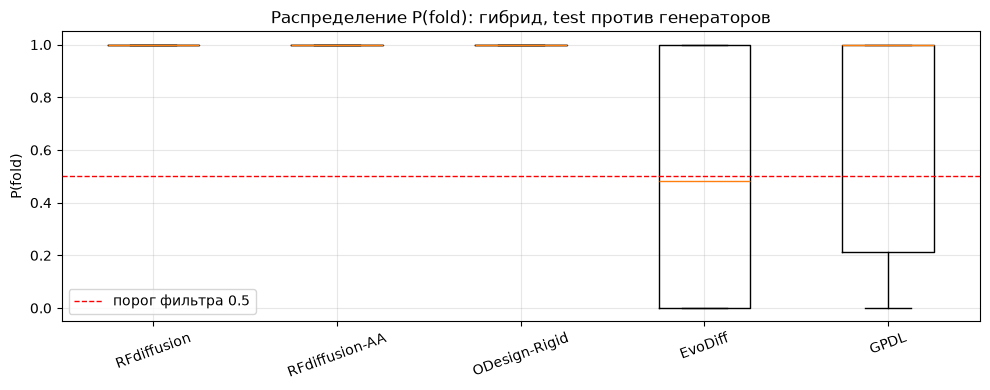

In [5]:
hyb = detail[detail["model"] == "hybrid"]
order = ["native_test", "decoy_test", "RFdiffusion", "RFdiffusion-AA",
         "ODesign-Rigid", "EvoDiff", "GPDL"]
groups = [g for g in order if g in set(hyb["group"])]

plt.boxplot([hyb.loc[hyb["group"] == g, "p_fold"] for g in groups],
            tick_labels=groups, showfliers=False)
plt.axhline(0.5, color="r", ls="--", lw=1, label="порог фильтра 0.5")
plt.ylabel("P(fold)")
plt.title("Распределение P(fold): гибрид, test против генераторов")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Доля структур, проходящих пороги, — то, что фактически отбирает фильтр
tab = hyb.groupby("group")["p_fold"].agg(n="count", mean="mean", median="median")
for thr in (0.5, 0.8):
    tab[f"frac > {thr}"] = hyb.groupby("group")["p_fold"].apply(
        lambda s, t=thr: (s > t).mean()
    )
tab.reindex(groups).round(3)

,n,mean,median,frac > 0.5,frac > 0.8
group,,,,,
RFdiffusion,3000,0.993,1.000,0.993,0.992
RFdiffusion-AA,3000,0.998,1.000,0.998,0.997
ODesign-Rigid,3000,0.999,1.000,0.999,0.999
EvoDiff,3000,0.498,0.481,0.499,0.470
GPDL,3000,0.724,1.000,0.727,0.695


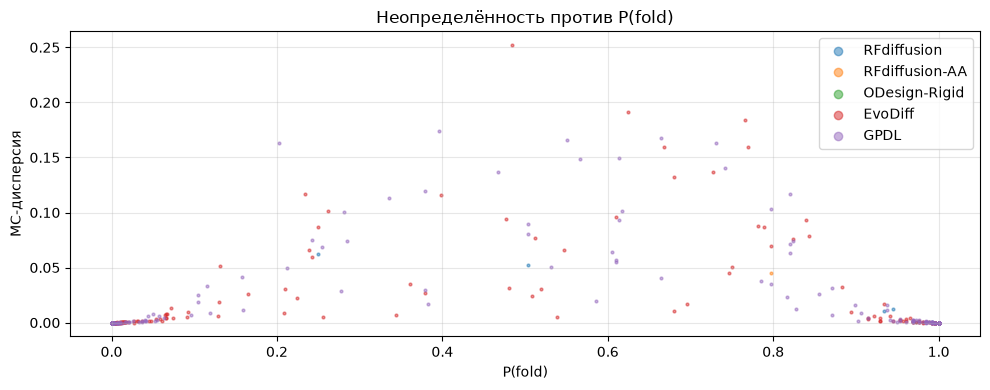

In [7]:
# Эпистемическая неопределённость против P(fold)
sub = hyb.sample(min(3000, len(hyb)), random_state=0)
for g in groups:
    d = sub[sub["group"] == g]
    plt.scatter(d["p_fold"], d["uncertainty"], s=4, alpha=0.5, label=g)
plt.xlabel("P(fold)")
plt.ylabel("MC-дисперсия")
plt.title("Неопределённость против P(fold)")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

## 3. Примеры: лучшие и худшие структуры

In [8]:
cols = ["group", "motif", "name", "length", "p_fold", "uncertainty"]
print("Топ-5 по P(fold):")
print(hyb.nlargest(5, "p_fold")[cols].to_string(index=False))
print("\nНижние 5 по P(fold):")
print(hyb.nsmallest(5, "p_fold")[cols].to_string(index=False))

Топ-5 по P(fold):
      group   motif           name  length  p_fold  uncertainty
RFdiffusion 01_1LDB  01_1LDB_0.pdb     125     1.0          0.0
RFdiffusion 01_1LDB  01_1LDB_1.pdb     125     1.0          0.0
RFdiffusion 01_1LDB 01_1LDB_10.pdb     125     1.0          0.0
RFdiffusion 01_1LDB 01_1LDB_11.pdb     125     1.0          0.0
RFdiffusion 01_1LDB 01_1LDB_12.pdb     125     1.0          0.0

Нижние 5 по P(fold):
      group   motif           name  length  p_fold  uncertainty
RFdiffusion 11_3TQB 11_3TQB_45.pdb     125     0.0          0.0
RFdiffusion 12_4JHW 12_4JHW_16.pdb     100     0.0          0.0
RFdiffusion 12_4JHW 12_4JHW_18.pdb     100     0.0          0.0
RFdiffusion 28_5YUI 28_5YUI_94.pdb      75     0.0          0.0
RFdiffusion 29_6CPA 29_6CPA_48.pdb     200     0.0          0.0


Полные таблицы метрик и интерпретация — в [05 — Эксперименты и результаты](../docs/05-eksperimenty-i-rezultaty.md). Фильтрация произвольных директорий со структурами — `filter_designability.py`.